In [1]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import numpy as np
import gtsam
import glob
import open3d as o3d
from tqdm import tqdm

In [2]:
cam0_images_path = "./img/machine_hall/MH_01_easy/mav0/cam0/data/*.png"
cam1_images_path = "./img/machine_hall/MH_01_easy/mav0/cam1/data/*.png"

min_features = 2000
N_FRAMES = 100
START_FRAME = 1000

# cam0 intrinsics (from sensor.yaml)
fx0, fy0, cx0, cy0 = 458.654, 457.296, 367.215, 248.375
K0 = np.array([[fx0, 0.0, cx0],
               [0.0, fy0, cy0],
               [0.0, 0.0, 1.0]], dtype=np.float64)
D0 = np.array([-0.28340811, 0.07395907, 0.00019359, 1.76187114e-05], dtype=np.float64)

# cam1 intrinsics (from sensor.yaml)
fx1, fy1, cx1, cy1 = 457.587, 456.134, 379.999, 255.238
K1 = np.array([[fx1, 0.0, cx1],
               [0.0, fy1, cy1],
               [0.0, 0.0, 1.0]], dtype=np.float64)
D1 = np.array([-0.28368365, 0.07451284, -0.00010473, -3.55590700e-05], dtype=np.float64)

# Body-to-sensor extrinsics (T_BS: sensor pose in body frame)
T_BS_cam0 = np.array([
    [ 0.0148655429818, -0.999880929698,   0.00414029679422, -0.0216401454975 ],
    [ 0.999557249008,   0.0149672133247,  0.025715529948,   -0.064676986768  ],
    [-0.0257744366974,  0.00375618835797, 0.999660727178,    0.00981073058949],
    [ 0.0,              0.0,              0.0,               1.0             ],
], dtype=np.float64)

T_BS_cam1 = np.array([
    [ 0.0125552670891, -0.999755099723,   0.0182237714554, -0.0198435579556 ],
    [ 0.999598781151,   0.0130119051815,  0.0251588363115,  0.0453689425024 ],
    [-0.0253898008918,  0.0179005838253,  0.999517347078,   0.00786212447038],
    [ 0.0,              0.0,              0.0,              1.0             ],
], dtype=np.float64)

# --- Stereo extrinsic (entrambe le direzioni esplicite) ---
# T_c0_c1 = "pose of cam1 in cam0 frame" = T_cam0_cam1.
#   -> trasforma un punto da cam1-frame a cam0-frame:   X_cam0 = T_c0_c1 @ X_cam1
#   -> e' il body_P_sensor richiesto da GTSAM per i fattori di cam1
# T_c1_c0 = inversa -> usata per costruire le matrici di proiezione verso cam1:
#   X_cam1 = T_c1_c0 @ X_cam0
T_c0_c1 = np.linalg.inv(T_BS_cam0) @ T_BS_cam1
T_c1_c0 = np.linalg.inv(T_c0_c1)

R_c0_c1, t_c0_c1 = T_c0_c1[:3, :3], T_c0_c1[:3, 3]
R_c1_c0, t_c1_c0 = T_c1_c0[:3, :3], T_c1_c0[:3, 3]

print("Stereo extrinsic cam0 <-> cam1:")
print(f"  baseline       : {np.linalg.norm(t_c0_c1) * 100:.2f} cm")
print(f"  cam1 origin in cam0 frame : [{t_c0_c1[0]:+.4f}, {t_c0_c1[1]:+.4f}, {t_c0_c1[2]:+.4f}] m")
print(f"  rotation angle : {np.degrees(np.arccos((np.trace(R_c0_c1) - 1) / 2)):.3f} deg")

# --- Load and sort stereo pairs ---
cam0_files = sorted(glob.glob(cam0_images_path))[START_FRAME:START_FRAME + N_FRAMES]
cam1_files = sorted(glob.glob(cam1_images_path))[START_FRAME:START_FRAME + N_FRAMES]

assert len(cam0_files) == N_FRAMES, f"cam0: only {len(cam0_files)} frames"
assert len(cam1_files) == N_FRAMES, f"cam1: only {len(cam1_files)} frames"
print(f"\nLoaded {N_FRAMES} stereo pairs")

# --- FAST detector (shared) ---
fast = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)


Stereo extrinsic cam0 <-> cam1:
  baseline       : 11.01 cm
  cam1 origin in cam0 frame : [+0.1101, -0.0002, +0.0009] m
  rotation angle : 0.818 deg

Loaded 100 stereo pairs


In [3]:
# --- Helper: detect new features and assign IDs ---
def detect_new_features(img, existing_ids):
    global next_feature_id
    keypoints = fast.detect(img, None)
    new_pts = []
    new_ids = []
    for kp in keypoints:
        x, y = kp.pt
        new_pts.append([x, y])
        new_ids.append(next_feature_id)
        tracked_points[next_feature_id] = (x, y)
        next_feature_id += 1
    return np.array(new_pts, dtype=np.float32).reshape(-1, 1, 2), new_ids

In [4]:
# --- Stereo tracking state ---
next_feature_id = 0                 # unique ID counter (shared across cameras)
tracked_points = {}                 # {id: (x,y)} - legacy
tracks_per_frame = []               # list of {"cam0": {id: (x,y)}, "cam1": {id: (x,y)}}

def load_gray_undistorted(path, K, D):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.undistort(img, K, D)

# Forward-backward check: matcho cam0 -> cam1 via LK, poi cam1 -> cam0 e scarto
# i punti il cui round-trip si discosta > FB_MAX_ERR dall'originale.
# E' il filtro standard per i match LK cross-camera, molto efficace su stereo
# ravvicinato (baseline ~11 cm, disparita' piccola).
FB_MAX_ERR = 1.0   # px

def stereo_match_lk(img_a, img_b, pts_a):
    """LK con forward-backward check. Ritorna (pts_b, valid_mask)."""
    if len(pts_a) == 0:
        return np.zeros((0, 1, 2), dtype=np.float32), np.zeros(0, dtype=bool)
    pts_b_fwd, st_fwd, _ = cv2.calcOpticalFlowPyrLK(img_a, img_b, pts_a, None)
    pts_a_bwd, st_bwd, _ = cv2.calcOpticalFlowPyrLK(img_b, img_a, pts_b_fwd, None)
    err = np.linalg.norm(pts_a.reshape(-1, 2) - pts_a_bwd.reshape(-1, 2), axis=1)
    valid = (st_fwd.flatten() == 1) & (st_bwd.flatten() == 1) & (err < FB_MAX_ERR)
    return pts_b_fwd, valid

# --- Frame 0: detect su cam0 + stereo match su cam1 ---
prev_img0 = load_gray_undistorted(cam0_files[0], K0, D0)
prev_img1 = load_gray_undistorted(cam1_files[0], K1, D1)
prev_pts0, prev_ids = detect_new_features(prev_img0, set())
pts1_0, valid_stereo_0 = stereo_match_lk(prev_img0, prev_img1, prev_pts0)

tracks_per_frame.append({
    "cam0": {pid: tuple(pt.ravel()) for pid, pt in zip(prev_ids, prev_pts0)},
    "cam1": {pid: tuple(pt.ravel())
             for pid, pt, v in zip(prev_ids, pts1_0, valid_stereo_0) if v},
})

# --- Loop temporale: LK cam0-in-tempo + LK cam0->cam1 a ogni frame ---
for cam0_fname, cam1_fname in tqdm(list(zip(cam0_files[1:], cam1_files[1:]))):
    frame0 = load_gray_undistorted(cam0_fname, K0, D0)
    frame1 = load_gray_undistorted(cam1_fname, K1, D1)

    # LK temporale su cam0
    next_pts0, status, _ = cv2.calcOpticalFlowPyrLK(prev_img0, frame0, prev_pts0, None)
    status = status.flatten()
    good_new = next_pts0[status == 1]
    good_ids = [pid for pid, st in zip(prev_ids, status) if st == 1]

    # Rabbocco feature cam0 se sotto soglia
    if len(good_new) < min_features:
        new_pts, new_ids = detect_new_features(frame0, set(good_ids))
        good_new = np.vstack([good_new.reshape(-1, 1, 2), new_pts])
        good_ids.extend(new_ids)

    # Stereo match cam0 -> cam1 sul frame corrente
    pts1_k, valid_stereo = stereo_match_lk(frame0, frame1, good_new.reshape(-1, 1, 2))

    tracks_per_frame.append({
        "cam0": {pid: pt.ravel() for pid, pt in zip(good_ids, good_new)},
        "cam1": {pid: pt.ravel()
                 for pid, pt, v in zip(good_ids, pts1_k, valid_stereo) if v},
    })

    prev_img0 = frame0
    prev_img1 = frame1
    prev_pts0 = good_new.reshape(-1, 1, 2)
    prev_ids  = good_ids

# --- Diagnostica ---
n_cam0 = [len(t["cam0"]) for t in tracks_per_frame[:5]]
n_cam1 = [len(t["cam1"]) for t in tracks_per_frame[:5]]
stereo_ratio = [f"{c1/c0:.1%}" if c0 else "-"
                for c0, c1 in zip(n_cam0, n_cam1)]
print(f"cam0 feature (primi 5 frame)   : {n_cam0}")
print(f"cam1 feature stereo (primi 5)  : {n_cam1}")
print(f"stereo match rate (primi 5)    : {stereo_ratio}")


100%|██████████| 99/99 [00:02<00:00, 37.48it/s]

cam0 feature (primi 5 frame)   : [1473, 2877, 2839, 2795, 2751]
cam1 feature stereo (primi 5)  : [1182, 2292, 2230, 2184, 2180]
stereo match rate (primi 5)    : ['80.2%', '79.7%', '78.5%', '78.1%', '79.2%']


In [5]:
# --- Stereo init al frame 0 ---
# Triangolo direttamente la coppia stereo cam0 <-> cam1 al primo frame.
# Nessun bootstrap E-matrix, nessuna ambiguita' di scala: il baseline (~11 cm) e'
# noto dalla calibrazione quindi i punti 3D escono direttamente in scala metrica.
#
# Convenzione: cam0 al frame 0 = origine mondo.
# Proiezione in cam1: per portare X_world (= X_cam0 al frame 0) in cam1 coords
# serve T_c1_c0 (NON T_c0_c1, che invece e' body_P_sensor per GTSAM).

P0_init = K0 @ np.hstack([np.eye(3), np.zeros((3, 1))])   # world -> cam0 px (identity)
P1_init = K1 @ T_c1_c0[:3, :]                             # world -> cam1 px

stereo_ids_0 = sorted(
    set(tracks_per_frame[0]["cam0"].keys()) & set(tracks_per_frame[0]["cam1"].keys())
)
pts_c0 = np.array([tracks_per_frame[0]["cam0"][pid] for pid in stereo_ids_0],
                  dtype=np.float64).T
pts_c1 = np.array([tracks_per_frame[0]["cam1"][pid] for pid in stereo_ids_0],
                  dtype=np.float64).T

points_h = cv2.triangulatePoints(P0_init, P1_init, pts_c0, pts_c1)
points_3d = (points_h[:3] / points_h[3]).T                # (N, 3) in cam0 coords = world
points_3d_ids = np.array(stereo_ids_0, dtype=np.int64)

# Cheirality in entrambe le camere + filtro outlier (depth < 100 m)
X_cam0 = points_3d
X_cam1 = (R_c1_c0 @ X_cam0.T + t_c1_c0.reshape(3, 1)).T
good = (
    ~np.isnan(X_cam0).any(axis=1) & ~np.isinf(X_cam0).any(axis=1)
    & (X_cam0[:, 2] > 0) & (X_cam1[:, 2] > 0)
    & (X_cam0[:, 2] < 100)
)
points_3d     = points_3d[good]
points_3d_ids = points_3d_ids[good]

print(f"Stereo init @ frame 0: {len(points_3d)} / {len(stereo_ids_0)} landmark validi")
print(f"  depth median  : {np.median(points_3d[:, 2]):.2f} m")
print(f"  depth p95     : {np.percentile(points_3d[:, 2], 95):.2f} m")
print(f"  depth p5      : {np.percentile(points_3d[:, 2], 5):.2f} m")


Stereo init @ frame 0: 1182 / 1182 landmark validi
  depth median  : 4.70 m
  depth p95     : 14.09 m
  depth p5      : 2.15 m


In [6]:
# --- Unified loop: PnP su cam0 + re-triangulation stereo ---
# Differenze chiave rispetto al monoculare:
#   - PnP usa solo le osservazioni cam0 (le cam1 servono solo per triangolare)
#   - Re-triangulation SEMPRE: il baseline stereo (~11 cm) e' sempre disponibile
#     e affidabile, non c'e' motivo di aspettare che gli inlier scendano come
#     si faceva nel monoculare (dove la baseline temporale non era garantita).
#   - Reprojection check: scarto triangolazioni con errore > 2 px in una delle
#     due camere, che protegge da match LK rumorosi.
#   - Nessun bootstrap: la mappa iniziale e' gia' stata creata dalla stereo init

MAX_REPROJ_ERR_INIT = 2.0   # px, filtro di accettazione per nuovi landmark

def stereo_triangulate_and_filter(pts0, pts1, T_world_cam0, T_world_cam1):
    """Triangolazione stereo + filtri cheirality + depth + reprojection.
    pts0, pts1: (2, N). Ritorna (X_world (N,3), valid_mask (N,))."""
    P_cam0 = K0 @ T_world_cam0[:3, :]
    P_cam1 = K1 @ T_world_cam1[:3, :]

    pts_h = cv2.triangulatePoints(P_cam0, P_cam1, pts0, pts1)
    X_world = (pts_h[:3] / pts_h[3]).T

    X_c0 = (T_world_cam0[:3, :3] @ X_world.T + T_world_cam0[:3, 3:4]).T
    X_c1 = (T_world_cam1[:3, :3] @ X_world.T + T_world_cam1[:3, 3:4]).T
    valid = (
        ~np.isnan(X_world).any(axis=1) & ~np.isinf(X_world).any(axis=1)
        & (X_c0[:, 2] > 0) & (X_c1[:, 2] > 0)
        & (X_c0[:, 2] < 100)
    )

    # Reprojection check
    X_h = np.hstack([X_world, np.ones((len(X_world), 1))])
    proj0 = (P_cam0 @ X_h.T).T
    proj1 = (P_cam1 @ X_h.T).T
    with np.errstate(divide="ignore", invalid="ignore"):
        uv0 = proj0[:, :2] / proj0[:, 2:3]
        uv1 = proj1[:, :2] / proj1[:, 2:3]
    err0 = np.linalg.norm(uv0 - pts0.T, axis=1)
    err1 = np.linalg.norm(uv1 - pts1.T, axis=1)
    valid &= (err0 < MAX_REPROJ_ERR_INIT) & (err1 < MAX_REPROJ_ERR_INIT)

    return X_world, valid

# Stato globale: mappa id -> 3D (world = cam0 @ frame 0), e pose per ogni frame
points_3d_map = {int(pid): X.astype(np.float64)
                 for pid, X in zip(points_3d_ids, points_3d)}
pose_per_frame = {0: (np.eye(3), np.zeros(3))}   # R, t: world -> cam0_k (OpenCV conv.)

for idx in tqdm(range(1, N_FRAMES)):
    cam0_pts = tracks_per_frame[idx]["cam0"]
    cam1_pts = tracks_per_frame[idx]["cam1"]

    # --- PnP su cam0 ---
    pts3d_list, pts2d_list = [], []
    for pid, X in points_3d_map.items():
        if pid in cam0_pts:
            pts3d_list.append(X)
            pts2d_list.append(cam0_pts[pid])
    if len(pts3d_list) < 6:
        raise ValueError(f"Frame {idx}: solo {len(pts3d_list)} match 2D-3D su cam0")

    pts3d_np = np.asarray(pts3d_list, dtype=np.float64)
    pts2d_np = np.asarray(pts2d_list, dtype=np.float64)

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        pts3d_np, pts2d_np, K0, distCoeffs=None, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not ok:
        raise RuntimeError(f"PnP failed for frame {idx}")

    R, _ = cv2.Rodrigues(rvec)
    t = tvec.ravel()
    pose_per_frame[idx] = (R, t)
    n_inliers = 0 if inliers is None else len(inliers)

    # --- Stereo re-triangulation: SEMPRE, per tutti i nuovi id con stereo match ---
    new_ids = [pid for pid in cam0_pts.keys()
               if pid in cam1_pts and pid not in points_3d_map]
    n_added = 0
    if len(new_ids) >= 10:
        pts0 = np.asarray([cam0_pts[pid] for pid in new_ids], dtype=np.float64).T
        pts1 = np.asarray([cam1_pts[pid] for pid in new_ids], dtype=np.float64).T

        T_world_cam0 = np.eye(4); T_world_cam0[:3, :3] = R; T_world_cam0[:3, 3] = t
        T_world_cam1 = T_c1_c0 @ T_world_cam0

        X_world, valid = stereo_triangulate_and_filter(pts0, pts1,
                                                       T_world_cam0, T_world_cam1)
        for pid, X, ok_mask in zip(new_ids, X_world, valid):
            if ok_mask:
                points_3d_map[int(pid)] = X
                n_added += 1

    if idx % 10 == 0 or n_added > 50:
        print(f"Frame {idx:3d}: inl={n_inliers:4d}, |map|={len(points_3d_map):5d}, +{n_added} nuovi")

# --- Array consumabili dalla BA ---
points_3d_ids = np.array(sorted(points_3d_map.keys()), dtype=np.int64)
points_3d     = np.array([points_3d_map[int(pid)] for pid in points_3d_ids],
                         dtype=np.float64)

initial_poses = []
for k in range(N_FRAMES):
    R, t = pose_per_frame[k]
    initial_poses.append((R, np.asarray(t).reshape(3, 1)))

print(f"\nTotale: {len(points_3d_ids)} landmark, {len(initial_poses)} pose")


 36%|███▋      | 36/99 [00:00<00:00, 351.86it/s]

Frame   1: inl=1159, |map|= 2306, +1124 nuovi
Frame  10: inl=1874, |map|= 2593, +4 nuovi
Frame  20: inl=1626, |map|= 2651, +0 nuovi
Frame  24: inl=1569, |map|= 4605, +1949 nuovi
Frame  30: inl=3451, |map|= 4682, +0 nuovi
Frame  40: inl=3138, |map|= 4682, +0 nuovi
Frame  50: inl=2863, |map|= 4682, +0 nuovi
Frame  60: inl=2510, |map|= 4682, +0 nuovi
Frame  70: inl=2201, |map|= 4682, +0 nuovi


100%|██████████| 99/99 [00:00<00:00, 347.97it/s]

Frame  80: inl=2060, |map|= 4682, +0 nuovi
Frame  90: inl=1811, |map|= 4682, +0 nuovi

Totale: 4682 landmark, 100 pose


In [7]:
# --- GTSAM stereo factor graph ---
# Variabili di ottimizzazione:
#   c_k  (Pose3)  = posa del rig (= cam0) al frame k, per k in [0, N)
#   p_i  (Point3) = posizione 3D del landmark i
# Nessuna variabile per cam1: le osservazioni cam1 entrano nel grafo come fattori
# che usano body_P_sensor=T_c0_c1, cosi' internamente GTSAM compone  cam0_pose * T_c0_c1
# per ottenere cam1_pose senza aggiungere gradi di liberta' superflui.

graph = gtsam.NonlinearFactorGraph()
initial_values = gtsam.Values()

cal0 = gtsam.Cal3_S2(fx0, fy0, 0, cx0, cy0)
cal1 = gtsam.Cal3_S2(fx1, fy1, 0, cx1, cy1)
sensor_pose_cam1 = gtsam.Pose3(T_c0_c1)   # body_P_sensor per i fattori di cam1

base_noise  = gtsam.noiseModel.Isotropic.Sigma(2, 1.0)
cauchy_mest = gtsam.noiseModel.mEstimator.Cauchy(1.0)
robust_noise = gtsam.noiseModel.Robust.Create(cauchy_mest, base_noise)

# --- Pose iniziali (cam0) ---
camera_ids = []
for idx, pose in enumerate(initial_poses):
    cam_sym = gtsam.symbol('c', int(idx))
    # OpenCV fornisce (R, t) world->cam, GTSAM vuole T_world_cam (cam in world) -> inverto
    cam_pose = gtsam.Pose3(gtsam.Rot3(pose[0]), pose[1]).inverse()
    initial_values.insert(cam_sym, cam_pose)
    camera_ids.append(cam_sym)

# Prior sulla prima posa (fissa il gauge)
pose_prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6] * 6))
graph.add(gtsam.PriorFactorPose3(gtsam.symbol('c', 0), gtsam.Pose3(), pose_prior_noise))

# --- Fattori di riproiezione cam0 + cam1 (traccio gli indici per diagnostica) ---
points_ids = []
cam0_factor_indices = []
cam1_factor_indices = []
for point_idx, point in zip(points_3d_ids, points_3d):
    obs_cam0 = [(k, tk["cam0"][point_idx])
                for k, tk in enumerate(tracks_per_frame) if point_idx in tk["cam0"]]
    obs_cam1 = [(k, tk["cam1"][point_idx])
                for k, tk in enumerate(tracks_per_frame) if point_idx in tk["cam1"]]
    if len(obs_cam0) + len(obs_cam1) < 3:
        continue

    point_sym = gtsam.symbol('p', int(point_idx))
    initial_values.insert(point_sym,
                          gtsam.Point3(float(point[0]), float(point[1]), float(point[2])))
    points_ids.append(point_sym)

    for k, pt2 in obs_cam0:
        z = gtsam.Point2(float(pt2[0]), float(pt2[1]))
        cam0_factor_indices.append(graph.size())
        graph.add(gtsam.GenericProjectionFactorCal3_S2(
            z, robust_noise, gtsam.symbol('c', int(k)), point_sym, cal0
        ))

    for k, pt2 in obs_cam1:
        z = gtsam.Point2(float(pt2[0]), float(pt2[1]))
        cam1_factor_indices.append(graph.size())
        graph.add(gtsam.GenericProjectionFactorCal3_S2(
            z, robust_noise, gtsam.symbol('c', int(k)), point_sym, cal1, sensor_pose_cam1
        ))

print(f"Landmark inseriti      : {len(points_ids)}")
print(f"Fattori cam0           : {len(cam0_factor_indices)}")
print(f"Fattori cam1           : {len(cam1_factor_indices)}")
print(f"Fattori totali proj.   : {len(cam0_factor_indices) + len(cam1_factor_indices)}")


Landmark inseriti      : 4648
Fattori cam0           : 272055
Fattori cam1           : 254639
Fattori totali proj.   : 526694


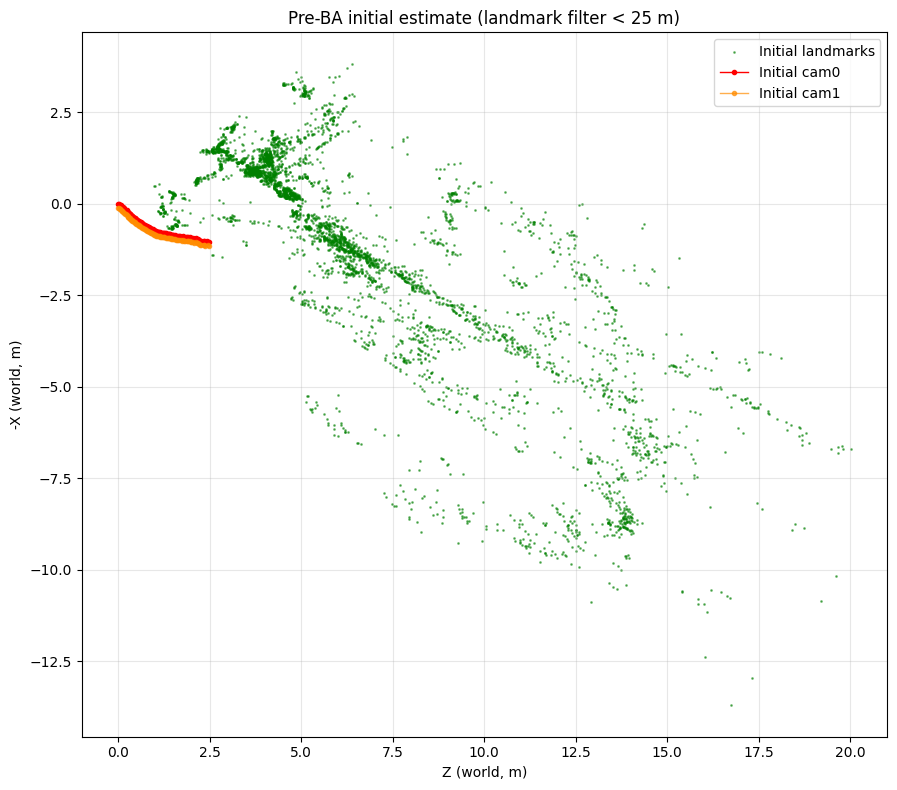

In [8]:
# --- Pre-BA initial estimate: top-down view (X-Z plane), entrambe le camere ---
# Le pose vengono dal PnP frame-by-frame (cam0) + composizione T_c0_c1 (cam1).
# I landmark sono quelli triangolati da stereo init + re-triangulation.

sensor_pose_cam1 = gtsam.Pose3(T_c0_c1)
LANDMARK_MAX_DIST_INIT_PLOT = 25.0   # m

init_cam0_xz, init_cam1_xz = [], []
for cam_sym in camera_ids:
    p0 = initial_values.atPose3(cam_sym)
    p1 = p0.compose(sensor_pose_cam1)
    init_cam0_xz.append((p0.translation()[2], -p0.translation()[0]))
    init_cam1_xz.append((p1.translation()[2], -p1.translation()[0]))
init_cam0_xz = np.array(init_cam0_xz)
init_cam1_xz = np.array(init_cam1_xz)

init_landmarks_xz = []
for sym in points_ids:
    p = initial_values.atPoint3(sym)
    if np.linalg.norm(p) > LANDMARK_MAX_DIST_INIT_PLOT or p[2] < 0:
        continue
    init_landmarks_xz.append((p[2], -p[0]))
init_landmarks_xz = np.array(init_landmarks_xz)

plt.figure(figsize=(16, 8))
plt.scatter(init_landmarks_xz[:, 0], init_landmarks_xz[:, 1],
            c='green', s=1, alpha=0.5, label='Initial landmarks')
plt.plot(init_cam0_xz[:, 0], init_cam0_xz[:, 1],
         'o-', color='red',         markersize=3, linewidth=1, label='Initial cam0')
plt.plot(init_cam1_xz[:, 0], init_cam1_xz[:, 1],
         'o-', color='darkorange',  markersize=3, linewidth=1, alpha=0.7, label='Initial cam1')
plt.gca().set_aspect('equal')
plt.xlabel('Z (world, m)')
plt.ylabel('-X (world, m)')
plt.title(f'Pre-BA initial estimate (landmark filter < {LANDMARK_MAX_DIST_INIT_PLOT:.0f} m)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./img/report/ba_medium/initial_estimate_topdown.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Optimize
params = gtsam.LevenbergMarquardtParams()
params.setVerbosity("TERMINATION")   # "SILENT", "SUMMARY", "TERMINATION"
params.setVerbosityLM("TERMINATION")   # "SILENT", "SUMMARY", "TERMINATION"
params.setMaxIterations(100)
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_values, params)
result = optimizer.optimize()
optimizer.print()

converged
errorThreshold: LevenbergMarquardtOptimizer
180043 <? 0
absoluteDecrease: 1.65641478664 <? 1e-05
relativeDecrease: 9.20002682117e-06 <? 1e-05
iterations: 66 >? 100
  parameters:

relative decrease threshold: 1e-05
absolute decrease threshold: 1e-05
      total error threshold: 0
         maximum iterations: 100
                  verbosity: TERMINATION
         linear solver type: MULTIFRONTAL CHOLESKY
                   ordering: COLAMD
              lambdaInitial: 1e-05
               lambdaFactor: 10
           lambdaUpperBound: 100000
           lambdaLowerBound: 0
           minModelFidelity: 0.001
            diagonalDamping: 0
                minDiagonal: 1e-06
                maxDiagonal: 1e+32
                verbosityLM: TERMINATION


In [10]:
# --- RMS di riproiezione spaccato per camera (diagnostica stereo) ---
def rms_for_indices(idx_list, result, graph):
    total_sq = 0.0
    for i in idx_list:
        r = graph.at(i).unwhitenedError(result)   # residuo raw in pixel, shape (2,)
        total_sq += float(np.sum(r ** 2))
    return (total_sq / len(idx_list)) ** 0.5 if idx_list else 0.0

def reproj_pixel_errs(idx_list, result, graph):
    errs = np.empty(len(idx_list))
    for i, gi in enumerate(idx_list):
        r = graph.at(gi).unwhitenedError(result)
        errs[i] = float(np.linalg.norm(r))
    return errs

rms_cam0 = rms_for_indices(cam0_factor_indices, result, graph)
rms_cam1 = rms_for_indices(cam1_factor_indices, result, graph)
rms_all  = rms_for_indices(cam0_factor_indices + cam1_factor_indices, result, graph)

errs0 = reproj_pixel_errs(cam0_factor_indices, result, graph)
errs1 = reproj_pixel_errs(cam1_factor_indices, result, graph)

print(f"Reprojection RMS su {len(cam0_factor_indices) + len(cam1_factor_indices)} osservazioni:")
print(f"  cam0 RMS  : {rms_cam0:.2f} px  (n={len(cam0_factor_indices)}, median err={np.median(errs0):.2f}, p95={np.percentile(errs0, 95):.2f})")
print(f"  cam1 RMS  : {rms_cam1:.2f} px  (n={len(cam1_factor_indices)}, median err={np.median(errs1):.2f}, p95={np.percentile(errs1, 95):.2f})")
print(f"  totale    : {rms_all:.2f} px")


Reprojection RMS su 526694 osservazioni:
  cam0 RMS  : 37.91 px  (n=272055, median err=0.48, p95=6.32)
  cam1 RMS  : 35.36 px  (n=254639, median err=0.46, p95=4.02)
  totale    : 36.70 px


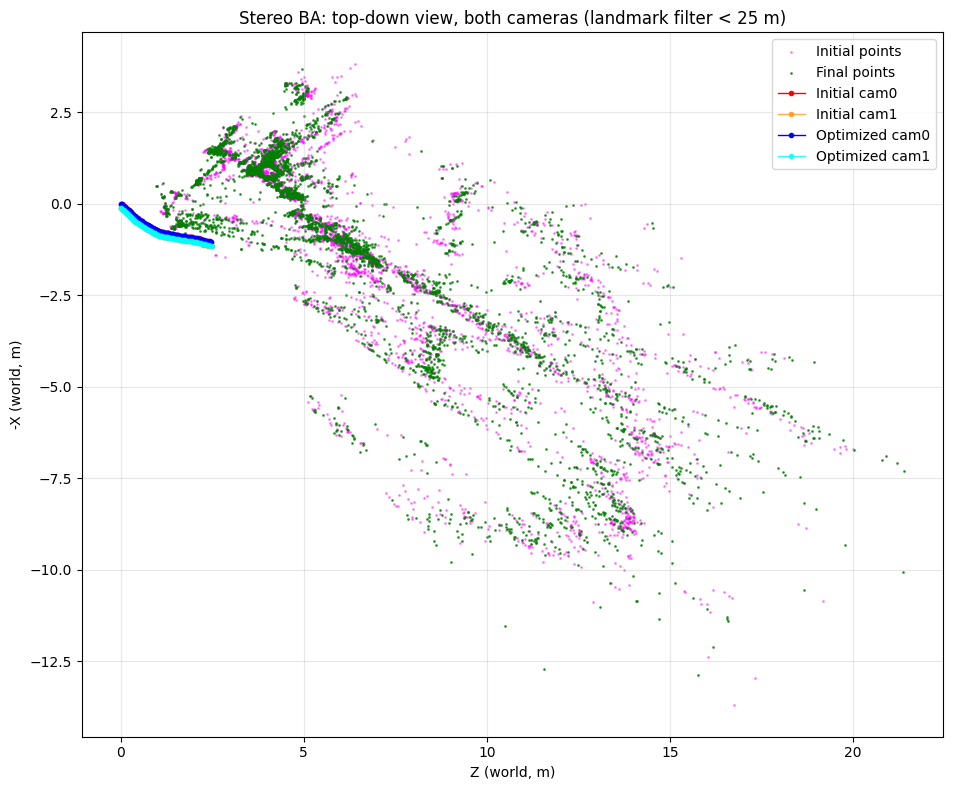

In [11]:
# --- Pre- vs post-BA: top-down view (X-Z plane), ENTRAMBE le camere ---
# Nessuno "scale hack": la BA stereo preserva la scala metrica nativa,
# quindi rimuovo la normalizzazione che serviva al monoculare.

sensor_pose_cam1 = gtsam.Pose3(T_c0_c1)
LANDMARK_MAX_DIST = 25.0   # m: filtro per evitare che outlier lontani sbilancino il plot

def traj_xz(values, cam_ids, include_cam1=True):
    cam0_xz, cam1_xz = [], []
    for sym in cam_ids:
        p0 = values.atPose3(sym)
        t0 = p0.translation()
        cam0_xz.append((t0[2], -t0[0]))
        if include_cam1:
            p1 = p0.compose(sensor_pose_cam1)
            t1 = p1.translation()
            cam1_xz.append((t1[2], -t1[0]))
    return np.array(cam0_xz), np.array(cam1_xz)

init_cam0_xz, init_cam1_xz   = traj_xz(initial_values, camera_ids)
final_cam0_xz, final_cam1_xz = traj_xz(result,         camera_ids)

# Landmark: tengo solo quelli in cui SIA iniziale SIA finale sono entro il cap
init_pts, final_pts = [], []
for sym in points_ids:
    X_init  = initial_values.atPoint3(sym)
    X_final = result.atPoint3(sym)
    if (np.linalg.norm(X_init)  > LANDMARK_MAX_DIST or X_init[2]  < 0
        or np.linalg.norm(X_final) > LANDMARK_MAX_DIST or X_final[2] < 0):
        continue
    init_pts.append((X_init[2],  -X_init[0]))
    final_pts.append((X_final[2], -X_final[0]))
init_pts  = np.array(init_pts)
final_pts = np.array(final_pts)

plt.figure(figsize=(16, 8))
plt.scatter(init_pts[:, 0],  init_pts[:, 1],  c='magenta', s=1, alpha=0.4, label='Initial points')
plt.scatter(final_pts[:, 0], final_pts[:, 1], c='green',   s=1, alpha=0.7, label='Final points')
plt.plot(init_cam0_xz[:, 0],  init_cam0_xz[:, 1],  'o-', color='red',        markersize=3, linewidth=1, label='Initial cam0')
plt.plot(init_cam1_xz[:, 0],  init_cam1_xz[:, 1],  'o-', color='darkorange', markersize=3, linewidth=1, alpha=0.7, label='Initial cam1')
plt.plot(final_cam0_xz[:, 0], final_cam0_xz[:, 1], 'o-', color='blue',       markersize=3, linewidth=1, label='Optimized cam0')
plt.plot(final_cam1_xz[:, 0], final_cam1_xz[:, 1], 'o-', color='cyan',       markersize=3, linewidth=1, alpha=0.8, label='Optimized cam1')
plt.gca().set_aspect('equal')
plt.xlabel('Z (world, m)')
plt.ylabel('-X (world, m)')
plt.title(f'Stereo BA: top-down view, both cameras (landmark filter < {LANDMARK_MAX_DIST:.0f} m)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./img/report/ba_medium/ba_comparison_topdown.png", dpi=150, bbox_inches="tight")
plt.show()


Salvati 4648 landmark in ba_medium_initial.ply (magenta)
Salvati 4646 landmark in ba_medium_final.ply   (verde)
Salvate traiettorie cam0/cam1 come .ply (blu/rosso)


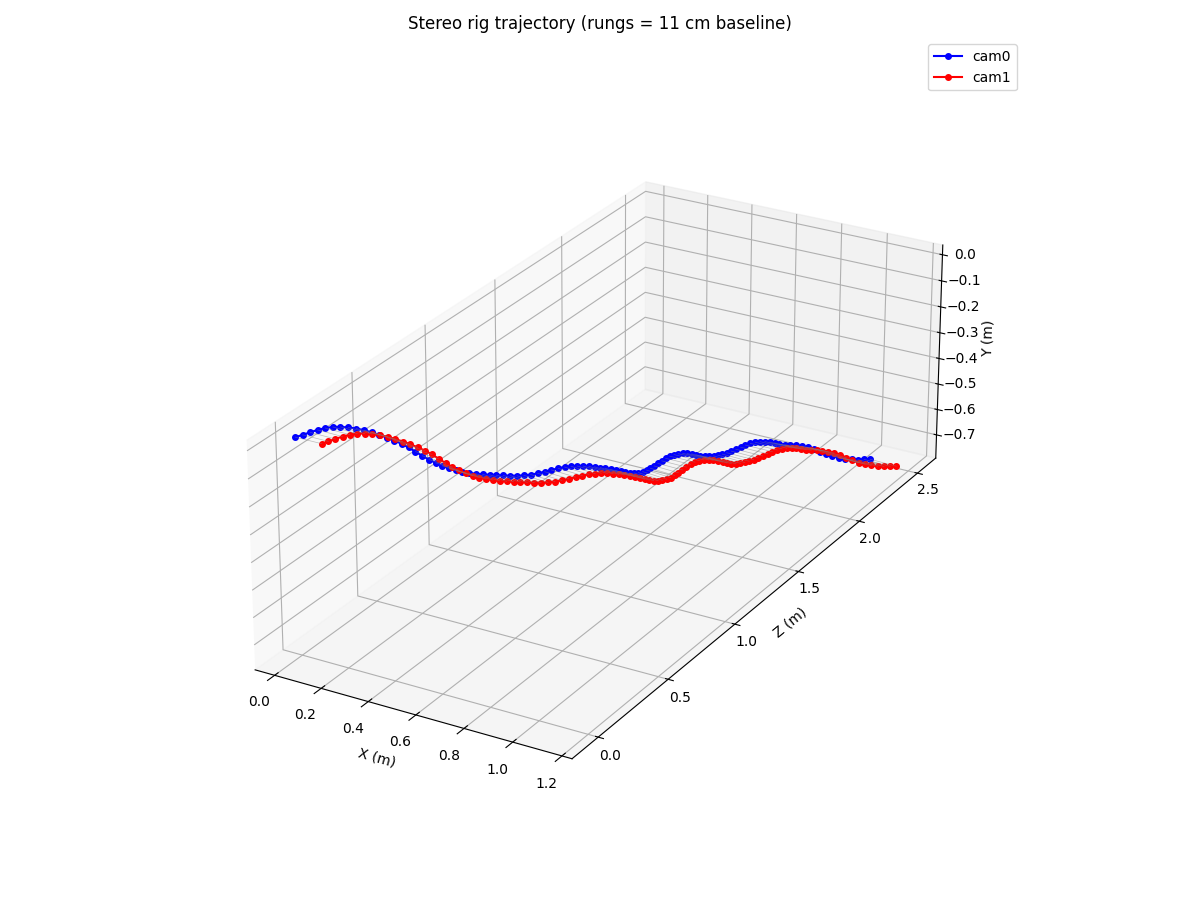

In [14]:
%matplotlib widget
# --- 3D view delle sole traiettorie stereo (metric scale) + save .ply ---
# Mostro solo le due traiettorie con rungs cam0<->cam1 a ogni posa: e' la
# visualizzazione che rende esplicita la larghezza del rig (11 cm baseline).
# Per il landmark cloud c'e' gia' la vista top-down di Cell 10 e, se serve
# una vista 3D interattiva, apri i .ply salvati con MeshLab.
from mpl_toolkits.mplot3d import Axes3D

sensor_pose_cam1 = gtsam.Pose3(T_c0_c1)

# Traiettorie cam0 e cam1 (cam1 derivata via T_c0_c1)
cam0_xyz, cam1_xyz = [], []
for sym in camera_ids:
    c0 = result.atPose3(sym)
    c1 = c0.compose(sensor_pose_cam1)
    cam0_xyz.append(c0.translation())
    cam1_xyz.append(c1.translation())
cam0_xyz = np.array(cam0_xyz)
cam1_xyz = np.array(cam1_xyz)

# --- Salva .ply: cloud iniziale (pre-BA) e finale (post-BA) per confronto in MeshLab ---
def save_landmark_ply(values, path, color, max_dist=100.0):
    pts = []
    for sym in points_ids:
        p = values.atPoint3(sym)
        if np.linalg.norm(p) > max_dist or p[2] < 0:
            continue
        pts.append([p[0], p[1], p[2]])
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.array(pts))
    pcd.paint_uniform_color(color)
    o3d.io.write_point_cloud(path, pcd)
    return len(pts)

n_init  = save_landmark_ply(initial_values, "./plot/medium/ba_medium_initial.ply", [0.9, 0.1, 0.6])  # magenta
n_final = save_landmark_ply(result,         "./plot/medium/ba_medium_final.ply",   [0.1, 0.7, 0.1])  # verde
print(f"Salvati {n_init} landmark in ba_medium_initial.ply (magenta)")
print(f"Salvati {n_final} landmark in ba_medium_final.ply   (verde)")

# Bonus: traiettorie come cloud di punti colorati (utile in MeshLab come overlay)
def save_trajectory_ply(xyz, path, color):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.paint_uniform_color(color)
    o3d.io.write_point_cloud(path, pcd)

save_trajectory_ply(cam0_xyz, "./plot/medium/ba_medium_cam0_traj.ply", [0.0, 0.3, 1.0])   # blu
save_trajectory_ply(cam1_xyz, "./plot/medium/ba_medium_cam1_traj.ply", [1.0, 0.2, 0.0])   # rosso
print("Salvate traiettorie cam0/cam1 come .ply (blu/rosso)")

# Matplotlib 3D widget, solo traiettorie con rungs.
# Mappatura assi: piano di moto X-Z sul pavimento del plot, Y (gravita') sull'asse
# verticale di matplotlib. Cosi' il movimento principale del drone e' visibile
# orizzontalmente e l'oscillazione verticale (~0.8 m) sull'asse mpl-Z.
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(cam0_xyz[:, 0], cam0_xyz[:, 2], cam0_xyz[:, 1], 'b-o', markersize=4, label='cam0')
ax.plot(cam1_xyz[:, 0], cam1_xyz[:, 2], cam1_xyz[:, 1], 'r-o', markersize=4, label='cam1')
for p0, p1 in zip(cam0_xyz, cam1_xyz):
    ax.plot([p0[0], p1[0]], [p0[2], p1[2]], [p0[1], p1[1]],
            color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_zlabel('Y (m)')
ax.set_title('Stereo rig trajectory (rungs = 11 cm baseline)')

# Box aspect proporzionale ai range reali (ordine: mpl-X=X, mpl-Y=Z, mpl-Z=Y)
all_xyz = np.vstack([cam0_xyz, cam1_xyz])
rx = all_xyz[:, 0].ptp()
ry = all_xyz[:, 1].ptp()
rz = all_xyz[:, 2].ptp()
ax.set_box_aspect([rx, rz, ry])

ax.view_init(elev=25, azim=-60)
ax.legend()
plt.tight_layout()
plt.savefig("./img/report/ba_medium/trajectory_comparison_3d.png", dpi=150, bbox_inches="tight")
plt.show()
